In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.append('2DHistogram')

#getting expected counts and the posterior for the weibull
from weibull_cache import weibull_expected_counts, get_weibull_posterior
from dataloader import samlet_df

Kategori
Bukser          70292
T-shirt         67757
Skjorte         17384
Jakke           17128
Overall         10151
Langærmet        7024
Busseron         6651
Kokkejakke       5625
Fleece           4355
Andet            3334
Forklæde         3152
Polo             2873
Kittel           2404
tunika           1774
Shorts           1349
cardigan         1071
jeans             986
softshell         631
undertrøje        561
nederdel          343
bluse             336
sjælevarm         251
fusion shirt      222
knickers           69
ziptrøje            7
Name: count, dtype: int64


In [5]:
cache_key = "Samlet__Alle"
posterior = get_weibull_posterior(days_array = samlet_df['Dage i cirkulation'].values,
cache_key = cache_key)
posterior

{'alpha_samples': array([1.20332372, 1.21048147, 1.20681024, ..., 1.20898758, 1.20688632,
        1.20827136], shape=(2000,)),
 'beta_samples': array([1223.97291282, 1230.91212999, 1225.18740146, ..., 1228.87418445,
        1224.37809706, 1225.84647055], shape=(2000,)),
 'method': 'mcmc',
 'n': 233980,
 'alpha_mean': 1.2079083594871567,
 'beta_mean': 1226.6453544958392,
 'alpha_hdi': (1.2042090869610427, 1.2115074009123186),
 'beta_hdi': (1222.2989746305861, 1230.4746214504503)}

In [10]:
n_bins = 100
counts, bin_edges = np.histogram(
    samlet_df['Dage i cirkulation'].values,
    bins = n_bins
)

expected_counts = weibull_expected_counts(
    alpha_samples = posterior['alpha_samples'],
    beta_samples = posterior['beta_samples'],
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2,
    bin_width = bin_edges[1] - bin_edges[0],
    n_total = posterior['n']
)
expected_counts

{'mean': array([1.18892455e+04, 1.40399700e+04, 1.45648047e+04, 1.44870734e+04,
        1.40928021e+04, 1.35149979e+04, 1.28294692e+04, 1.20842141e+04,
        1.13114433e+04, 1.05334593e+04, 9.76591092e+03, 9.01976667e+03,
        8.30259812e+03, 7.61945899e+03, 6.97351286e+03, 6.36649525e+03,
        5.79906188e+03, 5.27105554e+03, 4.78171331e+03, 4.32982862e+03,
        3.91387869e+03, 3.53212492e+03, 3.18269184e+03, 2.86362904e+03,
        2.57295941e+03, 2.30871635e+03, 2.06897202e+03, 1.85185847e+03,
        1.65558287e+03, 1.47843812e+03, 1.31880966e+03, 1.17517938e+03,
        1.04612704e+03, 9.30329967e+02, 8.26561297e+02, 7.33687109e+02,
        6.50662838e+02, 5.76529097e+02, 5.10407158e+02, 4.51494205e+02,
        3.99058504e+02, 3.52434572e+02, 3.11018417e+02, 2.74262918e+02,
        2.41673364e+02, 2.12803205e+02, 1.87250018e+02, 1.64651704e+02,
        1.44682934e+02, 1.27051817e+02, 1.11496822e+02, 9.77839191e+01,
        8.57039451e+01, 7.50701869e+01, 6.57161601e+01, 

In [12]:
chi_squared = 0
for i in range(n_bins):
    chi_squared += (counts[i] - expected_counts['mean'][i])**2 / expected_counts['mean'][i]
print(f"{chi_squared:.2f}")

10420.75


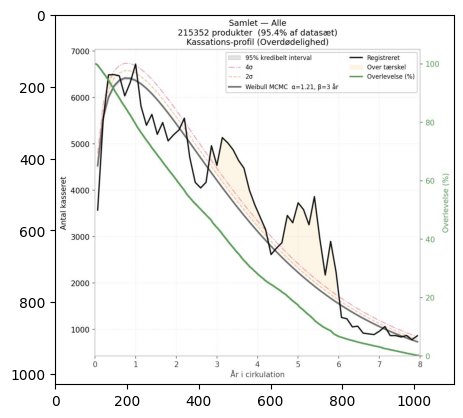

In [17]:
from PIL import Image
img = Image.open('Saved Histograms/Samlet_Alle_20260415_111822/histogram.jpeg')
plt.imshow(img)

# Tjekker fittet på området før 3 år

In [19]:
samlet_df_pre3aar = samlet_df[samlet_df['Dage i cirkulation'] < 365 * 3]

In [24]:
posterior = get_weibull_posterior(days_array = samlet_df_pre3aar['Dage i cirkulation'].values,
cache_key = "Samlet_pre3aar__Alle")

n_bins = 100
counts, bin_edges = np.histogram(
    samlet_df_pre3aar['Dage i cirkulation'].values,
    bins = n_bins
)

expected_counts = weibull_expected_counts(
    alpha_samples = posterior['alpha_samples'],
    beta_samples = posterior['beta_samples'],
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2,
    bin_width = bin_edges[1] - bin_edges[0],
    n_total = len(samlet_df_pre3aar)
)

chi_squared = 0
for i in range(n_bins):
    chi_squared += (counts[i] - expected_counts['mean'][i])**2 / expected_counts['mean'][i]
print(f"{chi_squared:.2f}")

21053.75


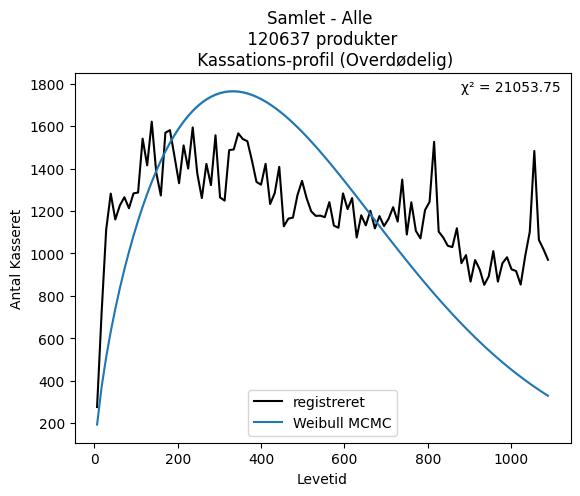

In [33]:
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, ax = plt.subplots()
ax.plot(bin_centers, counts, color="black", label="registreret")
ax.plot(bin_centers, expected_counts['mean'], label = "Weibull MCMC")
ax.fill_between(bin_centers, expected_counts['lower'], expected_counts['upper'], alpha=0.3)
ax.set_xlabel("Levetid")
ax.set_ylabel("Antal Kasseret")
ax.set_title(f"Samlet - Alle \n {len(samlet_df_pre3aar)} produkter \n Kassations-profil (Overdødelig)")
ax.text(0.98, 0.98, f"χ² = {chi_squared:.2f}", 
        transform=ax.transAxes,
        ha='right', va='top')
ax.legend()